# Analyse des courses cyclistes — Clustering & Statistiques descriptives

---
## Sommaire
1. Chargement et aperçu du dataset
2. Valeurs manquantes
3. Statistiques descriptives
4. Distribution des features clés
5. Clustering K-means (k=6)
6. Profil de chaque cluster
7. Visualisation PCA
8. Exemples de courses par cluster

## 0. Imports & Configuration

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import gpxpy
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

BASE       = '/Users/arthurdeletang/Desktop/Stage M1/Code/data'
GPX_DIR    = os.path.join(BASE, 'gpx_files_2')
MATCH_DIR  = os.path.join(BASE, 'matching', 'all')
INPUT_CSV  = os.path.join(MATCH_DIR, 'dataset_final.csv')
OUTPUT_CSV = os.path.join(MATCH_DIR, 'dataset_clustered.csv')

/Users/arthurdeletang/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/arthurdeletang/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Chargement et aperçu du dataset

In [2]:
df = pd.read_csv(INPUT_CSV)
print(f'Shape : {df.shape}')
print(f'Annees : {sorted(df["annee"].unique())}')
print(f'Categories : {df["categorie"].unique()}')
df.head(5)

Shape : (1796, 42)
Annees : [2024, 2025]
Categories : <StringArray>
[      'NC',      '2.2',    '2.UWT',      '1.1',      '1.2',    '1.UWT',
      '2.1',    '2.Pro',    '1.Pro',       'CC', 'Olympics',       'WC',
       'JR']
Length: 13, dtype: str


,jour,mois,annee,stage,nom_pcs,categorie,fichier_gpx,route_url,road_km,cycleway_km,street_km,unknown_km,state_road_km,off-grid_(unknown)_km,path_km,singletrack_km,asphalt_km,paved_km,cobblestones_km,unpaved_km,compacted_gravel_km,access_road_km,alpine_km,distance_gpx_km,denivele_pos,denivele_neg,altitude_max,altitude_min,n_cols_cat4,n_cols_cat3,n_cols_cat2,n_cols_cat1,n_cols_hc,loc_last_col_cat4,loc_last_col_cat3,loc_last_col_cat2,loc_last_col_cat1,loc_last_col_hc,gradient_last_1km,gradient_last_3km,gradient_last_5km,denivele_last_5km
0,4,1,2024,result,nc-australia-itt,NC,2024 Australian Road National Championships - ...,https://www.komoot.com/tour/2951626833,29.60,0.84,6.80,0.00,0.00,0.00,0.00,0.00,13.80,23.50,0.00,0.00,0.00,0.00,0.00,37.18,392.00,393.00,581.00,491.00,2.00,0.00,0.00,0.00,0.00,0.83,0.00,0.00,0.00,0.00,2.90,-0.70,-1.10,202.00
1,7,1,2024,result,nc-australia,NC,2024 Australian Road National Championships.gpx,https://www.komoot.com/tour/2951627291,87.70,14.80,23.60,0.00,14.30,0.00,0.00,0.00,17.50,123.00,0.00,0.00,0.00,0.00,0.00,139.88,2676.00,2676.00,599.00,442.00,12.00,0.00,0.00,0.00,0.00,0.94,0.00,0.00,0.00,0.00,-4.30,-1.90,-2.12,694.00
2,10,1,2024,stage_1,new-zealand-cycle-classic,2.2,2024 New Zealand Cycle Classic Stage 1.gpx,https://www.komoot.com/tour/2951835991,157.00,0.00,1.10,0.00,0.00,0.00,0.00,0.00,5.57,153.00,0.00,0.00,0.00,0.00,0.00,158.54,1487.00,1427.00,275.00,104.00,4.00,2.00,0.00,0.00,0.00,0.80,0.66,0.00,0.00,0.00,3.20,2.03,1.00,112.00
3,11,1,2024,stage_2,new-zealand-cycle-classic,2.2,2024 New Zealand Cycle Classic Stage 2.gpx,https://www.komoot.com/tour/2951837021,128.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,60.70,67.40,0.00,0.00,0.00,0.00,0.00,128.61,749.00,818.00,165.00,29.00,1.00,0.00,0.00,0.00,0.00,0.21,0.00,0.00,0.00,0.00,-0.90,-0.50,-0.28,30.00
4,12,1,2024,stage_3,new-zealand-cycle-classic,2.2,2024 New Zealand Cycle Classic Stage 3.gpx,https://www.komoot.com/tour/2951837434,127.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,54.70,72.40,0.00,0.00,0.00,0.00,0.00,127.00,1743.00,1357.00,486.00,68.00,5.00,3.00,3.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,6.90,3.00,2.66,377.00


In [3]:
print('Repartition par annee :')
print(df['annee'].value_counts().sort_index())
print('\nRepartition par categorie :')
print(df['categorie'].value_counts())
print('\nRepartition par type detape :')
print(df['stage'].value_counts().head(10))

Repartition par annee :
annee
2024    890
2025    906
Name: count, dtype: int64

Repartition par categorie :
categorie
2.2         580
2.UWT       287
2.1         250
2.Pro       234
1.2         141
1.1         115
1.Pro        66
NC           56
1.UWT        41
CC           18
WC            4
JR            3
Olympics      1
Name: count, dtype: int64

Repartition par type detape :
stage
result     445
stage_1    249
stage_2    247
stage_3    235
stage_4    199
stage_5    150
stage_6     65
stage_7     48
stage_8     36
stage_9     20
Name: count, dtype: int64


## 2. Valeurs manquantes

In [4]:
nan_df = pd.DataFrame({
    'n_manquants': df.isna().sum(),
    'pct_manquants': (df.isna().sum() / len(df) * 100).round(1)
})
nan_df = nan_df[nan_df['n_manquants'] > 0].sort_values('pct_manquants', ascending=False)
print(f'Colonnes sans valeurs manquantes : {(df.isna().sum() == 0).sum()}/{len(df.columns)}')
print(f'Colonnes avec valeurs manquantes : {len(nan_df)}')
nan_df

Colonnes sans valeurs manquantes : 23/42
Colonnes avec valeurs manquantes : 19


,n_manquants,pct_manquants
distance_gpx_km,47,2.60
loc_last_col_cat4,47,2.60
gradient_last_5km,47,2.60
gradient_last_3km,47,2.60
gradient_last_1km,47,2.60
loc_last_col_hc,47,2.60
loc_last_col_cat1,47,2.60
loc_last_col_cat2,47,2.60
loc_last_col_cat3,47,2.60
n_cols_hc,47,2.60


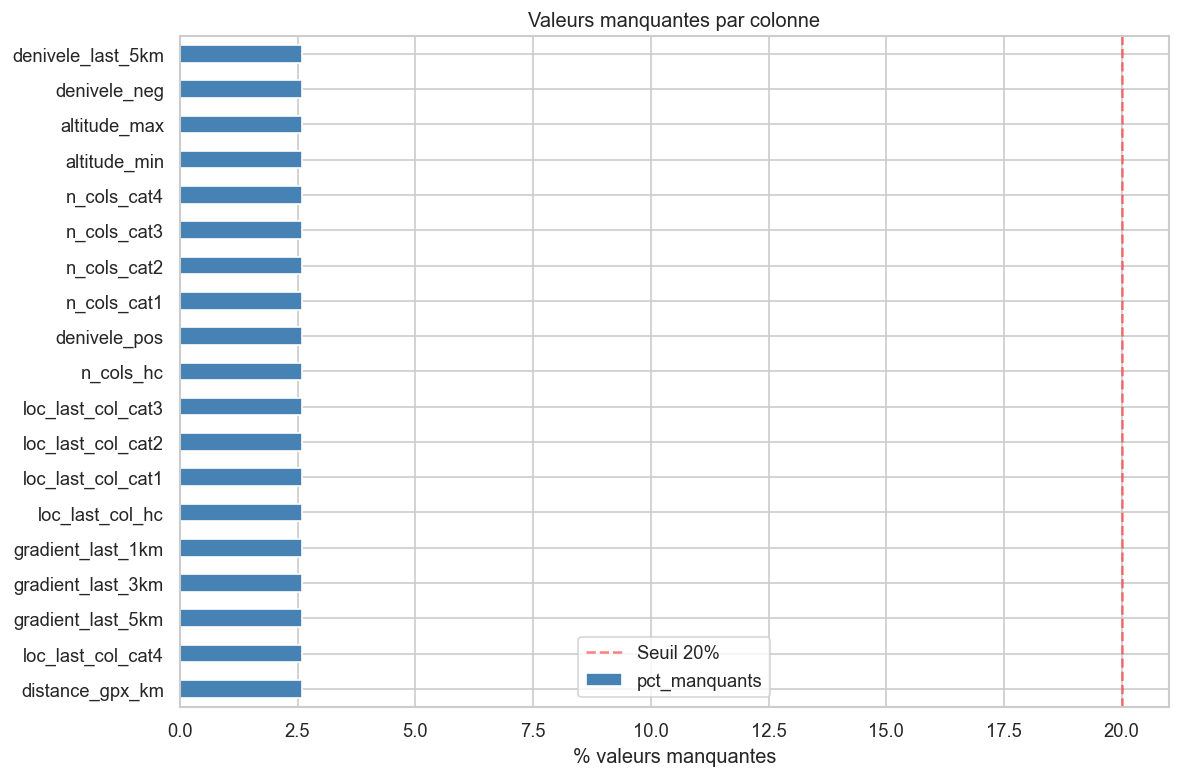

In [5]:
# Visualisation des valeurs manquantes
if len(nan_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(nan_df) * 0.35)))
    nan_df['pct_manquants'].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('% valeurs manquantes')
    ax.set_title('Valeurs manquantes par colonne')
    ax.axvline(x=20, color='red', linestyle='--', alpha=0.5, label='Seuil 20%')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [21]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df[df.isnull().any(axis=1)][['fichier_gpx', 'annee', 'categorie'] + [c for c in df.columns if df[c].isna().any()]]

,fichier_gpx,annee,categorie,distance_gpx_km,denivele_pos,denivele_neg,altitude_max,altitude_min,n_cols_cat4,n_cols_cat3,n_cols_cat2,n_cols_cat1,n_cols_hc,loc_last_col_cat4,loc_last_col_cat3,loc_last_col_cat2,loc_last_col_cat1,loc_last_col_hc,gradient_last_1km,gradient_last_3km,gradient_last_5km,denivele_last_5km
80,2024 Tour of Oman Stage 4.gpx,2024,2.Pro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
82,2024 Tour of Oman Stage 5.gpx,2024,2.Pro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
296,2024 GP Vorarlberg b/by Radhaus Rankweil.gpx,2024,1.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
347,2024 4 Jours de Dunkerque / Grand Prix des Hau...,2024,2.Pro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
350,2024 4 Jours de Dunkerque / Grand Prix des Hau...,2024,2.Pro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
353,2024 4 Jours de Dunkerque / Grand Prix des Hau...,2024,2.Pro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
356,2024 4 Jours de Dunkerque / Grand Prix des Hau...,2024,2.Pro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,2024 4 Jours de Dunkerque / Grand Prix des Hau...,2024,2.Pro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,2024 Antwerp Port Epic / Sels Trophy.gpx,2024,1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,2024 4 Jours de Dunkerque / Grand Prix des Hau...,2024,2.Pro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
import os
GPX_DIR = '/Users/arthurdeletang/Desktop/Stage M1/Code/data/gpx_files_2'
fichiers = os.listdir(GPX_DIR)
# Chercher les 4 Jours de Dunkerque
[f for f in fichiers if 'Dunkerque' in f or 'dunkerque' in f.lower()]

['2019 4 Jours de Dunkerque .gpx',
 '2022 4 Jours de Dunkerque .gpx',
 '2025 4 Jours de Dunkerque .gpx',
 '2025 Classique Dunkerque .gpx',
 '2017 4 Jours de Dunkerque .gpx',
 '2024 4 Jours de Dunkerque .gpx',
 '2023 4 Jours de Dunkerque .gpx',
 '2018 4 Jours de Dunkerque .gpx']

In [25]:
path = find_gpx_path('2024 4 Jours de Dunkerque / Grand Prix des Hauts de France Stage 1.gpx', GPX_DIR)
print(path)
gpx = parse_gpx_safe(path)
print(len(gpx.tracks[0].segments[0].points), 'points')

NameError: name 'find_gpx_path' is not defined

## 3. Statistiques descriptives

In [6]:
features_desc = [
    'distance_gpx_km', 'denivele_pos', 'denivele_neg', 'altitude_max', 'altitude_min',
    'n_cols_cat4', 'n_cols_cat3', 'n_cols_cat2', 'n_cols_cat1', 'n_cols_hc',
    'gradient_last_1km', 'gradient_last_3km', 'gradient_last_5km', 'denivele_last_5km',
    'road_km', 'cycleway_km', 'asphalt_km', 'paved_km', 'cobblestones_km',
]
features_desc = [f for f in features_desc if f in df.columns]
df[features_desc].describe().round(1)

,distance_gpx_km,denivele_pos,denivele_neg,altitude_max,altitude_min,n_cols_cat4,n_cols_cat3,n_cols_cat2,n_cols_cat1,n_cols_hc,gradient_last_1km,gradient_last_3km,gradient_last_5km,denivele_last_5km,road_km,cycleway_km,asphalt_km,paved_km,cobblestones_km
count,1749.00,1749.00,1749.00,1749.00,1749.00,1749.00,1749.00,1749.00,1749.00,1749.00,1749.00,1749.00,1749.00,1749.00,1796.00,1796.00,1796.00,1796.00,1796.00
mean,147.10,1687.80,1555.50,691.50,244.00,4.20,2.00,0.80,0.30,0.20,1.60,1.00,0.80,175.30,78.20,7.10,121.40,12.50,1.00
std,50.20,1060.50,959.40,730.90,504.90,3.70,2.20,1.10,0.60,0.50,3.10,2.80,2.60,183.80,57.60,18.20,58.40,22.00,3.60
min,0.90,1.00,0.00,1.00,-12.00,0.00,0.00,0.00,0.00,0.00,-7.90,-7.90,-8.30,0.00,0.00,0.00,0.00,0.00,0.00
25%,126.10,826.00,767.00,171.00,4.00,1.00,0.00,0.00,0.00,0.00,-0.10,-0.30,-0.30,49.00,20.50,0.00,93.80,0.30,0.00
50%,157.80,1648.00,1542.00,460.00,59.00,4.00,1.00,0.00,0.00,0.00,0.40,0.10,0.00,111.00,81.30,0.00,137.00,3.10,0.00
75%,180.00,2407.00,2240.00,914.00,227.00,6.00,3.00,1.00,0.00,0.00,2.80,1.40,0.90,237.00,125.00,3.80,164.00,13.00,0.20
max,290.40,5794.00,4853.00,4401.00,3838.00,28.00,13.00,6.00,4.00,3.00,15.90,13.10,11.80,1142.00,238.00,146.00,283.00,153.00,52.10


## 4. Distribution des features clés

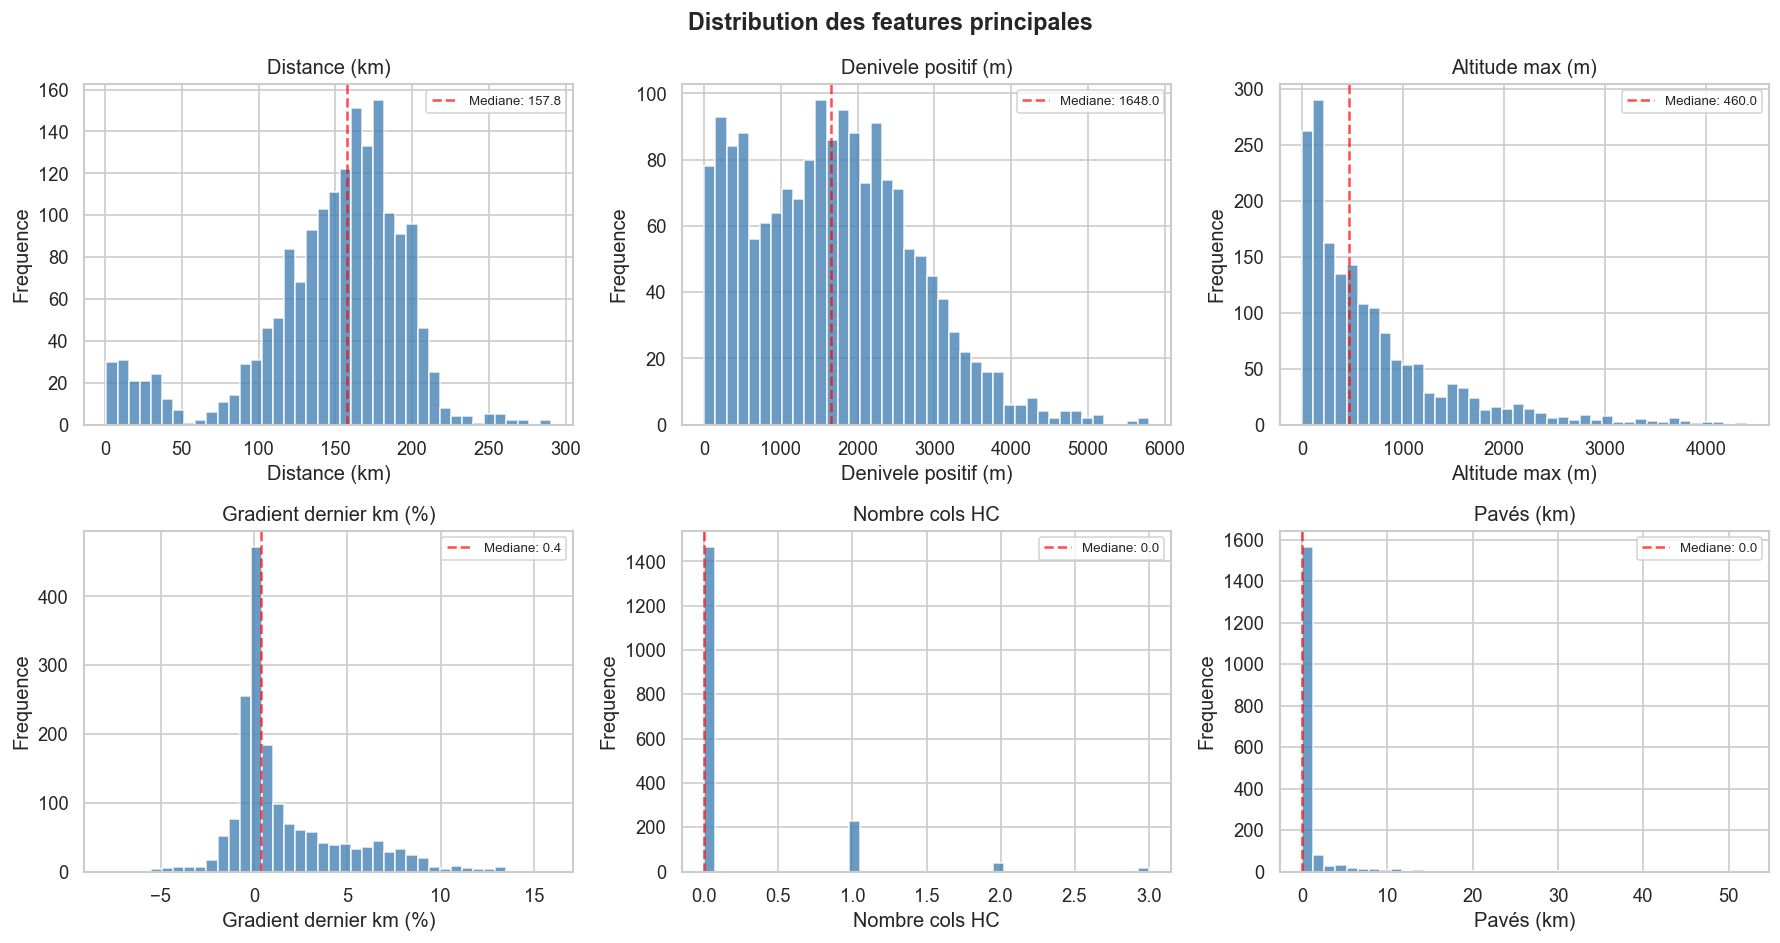

In [7]:
features_plot = [
    ('distance_gpx_km', 'Distance (km)'),
    ('denivele_pos', 'Denivele positif (m)'),
    ('altitude_max', 'Altitude max (m)'),
    ('gradient_last_1km', 'Gradient dernier km (%)'),
    ('n_cols_hc', 'Nombre cols HC'),
    ('cobblestones_km', 'Pavés (km)'),
]
features_plot = [(f, l) for f, l in features_plot if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, (feat, label) in enumerate(features_plot):
    data = df[feat].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(label)
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Frequence')
    axes[i].axvline(data.median(), color='red', linestyle='--', alpha=0.7, label=f'Mediane: {data.median():.1f}')
    axes[i].legend(fontsize=8)
plt.suptitle('Distribution des features principales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

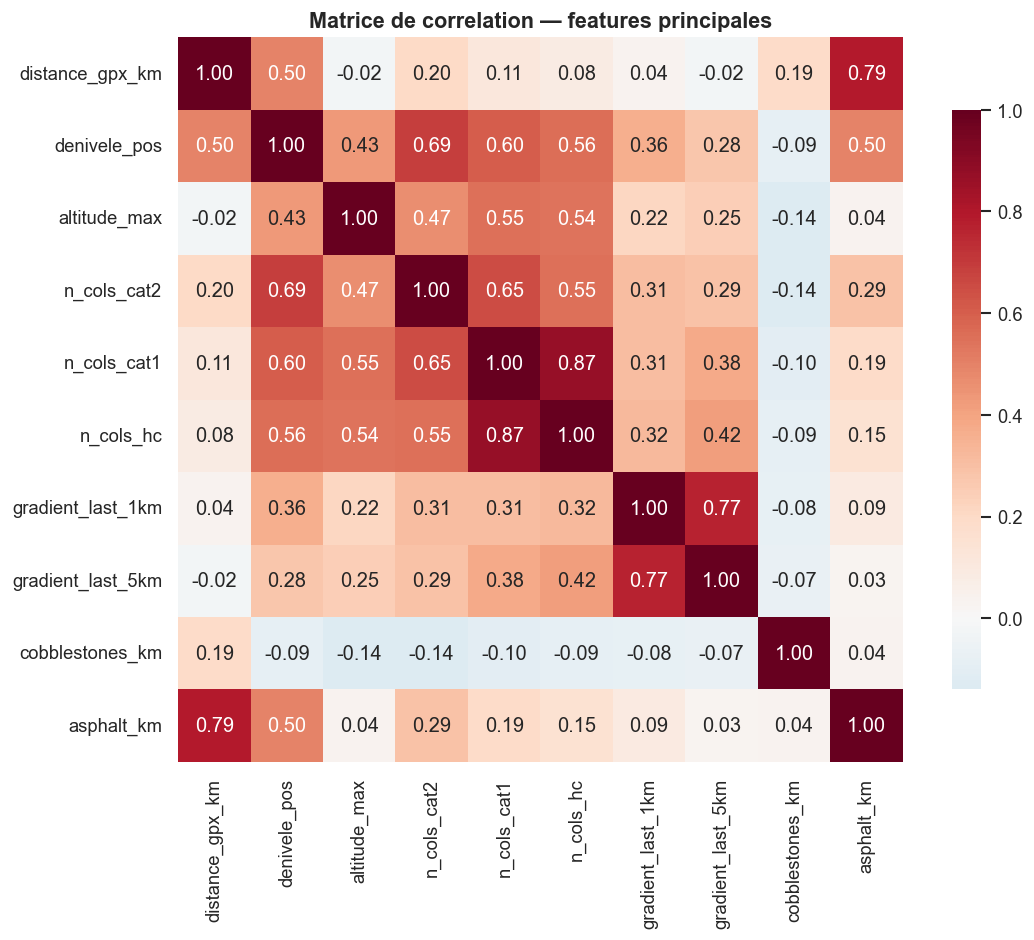

In [8]:
# Matrice de correlation
corr_features = [
    'distance_gpx_km', 'denivele_pos', 'altitude_max',
    'n_cols_cat2', 'n_cols_cat1', 'n_cols_hc',
    'gradient_last_1km', 'gradient_last_5km',
    'cobblestones_km', 'asphalt_km',
]
corr_features = [f for f in corr_features if f in df.columns]
corr_matrix = df[corr_features].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de correlation — features principales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Clustering K-means

In [26]:
# Classification regle metier
def classify_race_type(row):
    stage  = str(row.get('stage', '')).lower()
    cat    = str(row.get('categorie', '')).upper()
    deniv  = row.get('denivele_pos', 0) or 0
    dist   = row.get('distance_gpx_km', 0) or 0
    n_hc   = row.get('n_cols_hc', 0) or 0
    n_c1   = row.get('n_cols_cat1', 0) or 0
    n_c2   = row.get('n_cols_cat2', 0) or 0
    grad1  = row.get('gradient_last_1km', 0) or 0
    cobble = row.get('cobblestones_km', 0) or 0
    if stage == 'prologue' or (dist < 60 and deniv / max(dist, 1) < 10):
        return 'CLM'
    if cat in ['NC', 'CC', 'WC', 'JR', 'OLYMPICS']:
        return 'autre'
    if n_hc >= 2 or (n_hc >= 1 and deniv > 3500):
        return 'haute_montagne'
    if n_c1 >= 2 or (n_c1 >= 1 and deniv > 2500) or (n_c2 >= 3 and deniv > 3000):
        return 'montagne'
    if cobble > 5:
        return 'pavees'
    if grad1 > 4 and n_c2 >= 1:
        return 'arrivee_en_cote'
    if deniv > 2000 or n_c2 >= 2:
        return 'accidentee'
    return 'sprint'

df['type_course'] = df.apply(classify_race_type, axis=1)

# Encodage
cat_order = {
    '2.2': 1, '2.1': 2, '2.Pro': 3, '2.UWT': 4,
    '1.2': 1, '1.1': 2, '1.Pro': 3, '1.UWT': 4,
    'NC': 0, 'CC': 0, 'WC': 5, 'JR': 0, 'Olympics': 5
}
df['niveau_uci'] = df['categorie'].map(cat_order).fillna(1)
df['is_stage_race'] = df['stage'].apply(lambda x: 0 if str(x).lower() == 'result' else 1)

print('Type de course :')
print(df['type_course'].value_counts())

Type de course :
type_course
sprint             838
accidentee         342
montagne           161
arrivee_en_cote    132
CLM                 92
pavees              88
haute_montagne      84
autre               59
Name: count, dtype: int64


In [27]:
# Features pour le clustering
features_gpx = [
    'distance_gpx_km', 'denivele_pos', 'denivele_neg',
    'altitude_max', 'altitude_min',
    'n_cols_cat4', 'n_cols_cat3', 'n_cols_cat2', 'n_cols_cat1', 'n_cols_hc',
    'loc_last_col_cat2', 'loc_last_col_cat1', 'loc_last_col_hc',
    'gradient_last_1km', 'gradient_last_3km', 'gradient_last_5km',
    'denivele_last_5km',
]
features_komoot = [
    c for c in df.columns
    if c.endswith('_km') and c not in ['distance_gpx_km']
]
features_cluster = [f for f in features_gpx + features_komoot if f in df.columns]

df_cluster = df[df['distance_gpx_km'].notna()].copy()
X = df_cluster[features_cluster].copy()

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

print(f'Courses pour clustering : {len(df_cluster)}')
print(f'Features utilisees : {len(features_cluster)}')

Courses pour clustering : 1749
Features utilisees : 32


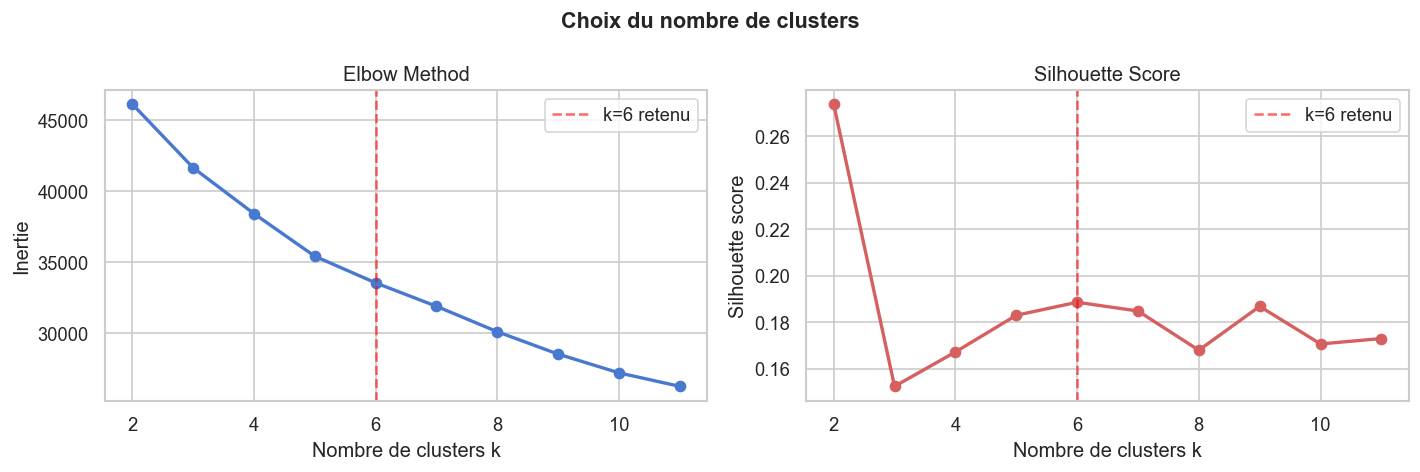

Silhouette k=6 : 0.189


In [28]:
# Elbow + Silhouette
inertias, silhouettes = [], []
K_range = range(2, 12)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=6)
ax1.set_xlabel('Nombre de clusters k')
ax1.set_ylabel('Inertie')
ax1.set_title('Elbow Method')
ax1.axvline(x=6, color='red', linestyle='--', alpha=0.6, label='k=6 retenu')
ax1.legend()
ax2.plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=6)
ax2.set_xlabel('Nombre de clusters k')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette Score')
ax2.axvline(x=6, color='red', linestyle='--', alpha=0.6, label='k=6 retenu')
ax2.legend()
plt.suptitle('Choix du nombre de clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Silhouette k=6 : {silhouettes[4]:.3f}')

In [29]:
K = 6
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df_cluster['cluster'] = km_final.fit_predict(X_scaled)

# Labels semantiques
labels_clusters = {
    0: 'montagne',
    1: 'sprint_pave',
    2: 'court_plat',
    3: 'accidente_altitude',
    4: 'semi_montagne_pave',
    5: 'accidente_long'
}
df_cluster['cluster_label'] = df_cluster['cluster'].map(labels_clusters)

print('Distribution des clusters :')
print(df_cluster['cluster_label'].value_counts())

Distribution des clusters :
cluster_label
accidente_long        649
court_plat            620
montagne              252
sprint_pave           144
accidente_altitude     63
semi_montagne_pave     21
Name: count, dtype: int64


## 6. Profil de chaque cluster

In [13]:
features_profil = [
    'distance_gpx_km', 'denivele_pos', 'altitude_max',
    'n_cols_hc', 'n_cols_cat1', 'n_cols_cat2',
    'gradient_last_1km', 'gradient_last_5km',
    'cobblestones_km', 'asphalt_km', 'road_km'
]
features_profil = [f for f in features_profil if f in df_cluster.columns]

profil = df_cluster.groupby('cluster_label')[features_profil].mean().round(1)
profil

,distance_gpx_km,denivele_pos,altitude_max,n_cols_hc,n_cols_cat1,n_cols_cat2,gradient_last_1km,gradient_last_5km,cobblestones_km,asphalt_km,road_km
cluster_label,,,,,,,,,,,
accidente_altitude,143.70,1416.40,1101.30,0.20,0.20,0.80,1.30,0.70,0.00,17.70,6.50
accidente_long,168.40,2224.20,680.20,0.10,0.20,1.10,1.70,0.30,0.40,155.30,108.30
court_plat,112.80,739.40,404.10,0.00,0.00,0.10,0.40,0.00,0.30,98.10,55.70
montagne,153.90,2981.60,1650.70,1.20,1.40,2.20,5.00,4.30,0.20,145.20,81.00
semi_montagne_pave,168.30,1554.30,410.70,0.00,0.00,0.50,1.20,0.10,3.30,98.80,89.30
sprint_pave,185.30,1227.00,162.60,0.00,0.00,0.00,0.50,-0.00,8.40,115.00,90.00


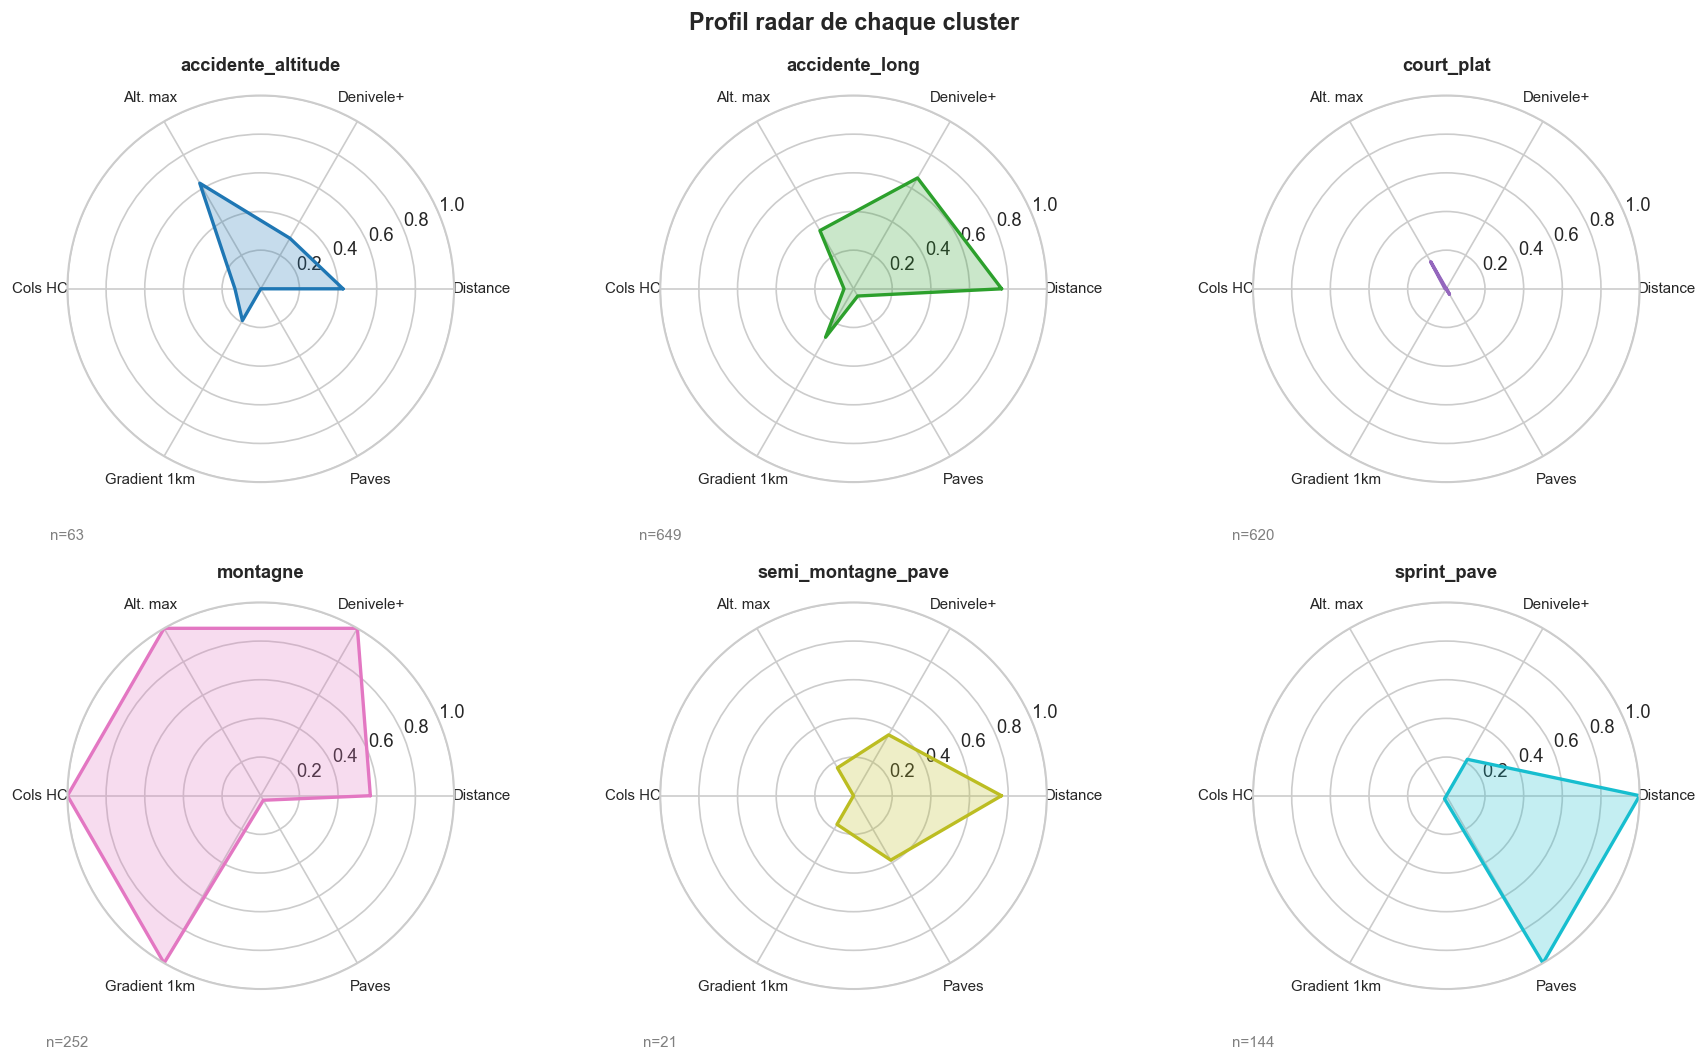

In [14]:
# Radar chart par cluster
from matplotlib.patches import FancyArrowPatch

features_radar = [
    'distance_gpx_km', 'denivele_pos', 'altitude_max',
    'n_cols_hc', 'gradient_last_1km', 'cobblestones_km'
]
features_radar = [f for f in features_radar if f in df_cluster.columns]
labels_radar = ['Distance', 'Denivele+', 'Alt. max', 'Cols HC', 'Gradient 1km', 'Paves']
labels_radar = labels_radar[:len(features_radar)]

# Normaliser 0-1 pour le radar
profil_radar = df_cluster.groupby('cluster_label')[features_radar].mean()
profil_norm = (profil_radar - profil_radar.min()) / (profil_radar.max() - profil_radar.min() + 1e-9)

N = len(features_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(15, 9), subplot_kw=dict(polar=True))
axes = axes.flatten()
colors = cm.tab10(np.linspace(0, 1, K))

for i, (label, row) in enumerate(profil_norm.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    axes[i].plot(angles, vals, color=colors[i], linewidth=2)
    axes[i].fill(angles, vals, color=colors[i], alpha=0.25)
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(labels_radar, fontsize=9)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(label, fontsize=11, fontweight='bold', pad=15)
    n = (df_cluster['cluster_label'] == label).sum()
    axes[i].text(0, -0.15, f'n={n}', transform=axes[i].transAxes,
                ha='center', fontsize=9, color='gray')

plt.suptitle('Profil radar de chaque cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Visualisation PCA

Variance expliquee PC1+PC2 : 36.6%
PC1 : 24.6%
PC2 : 12.0%


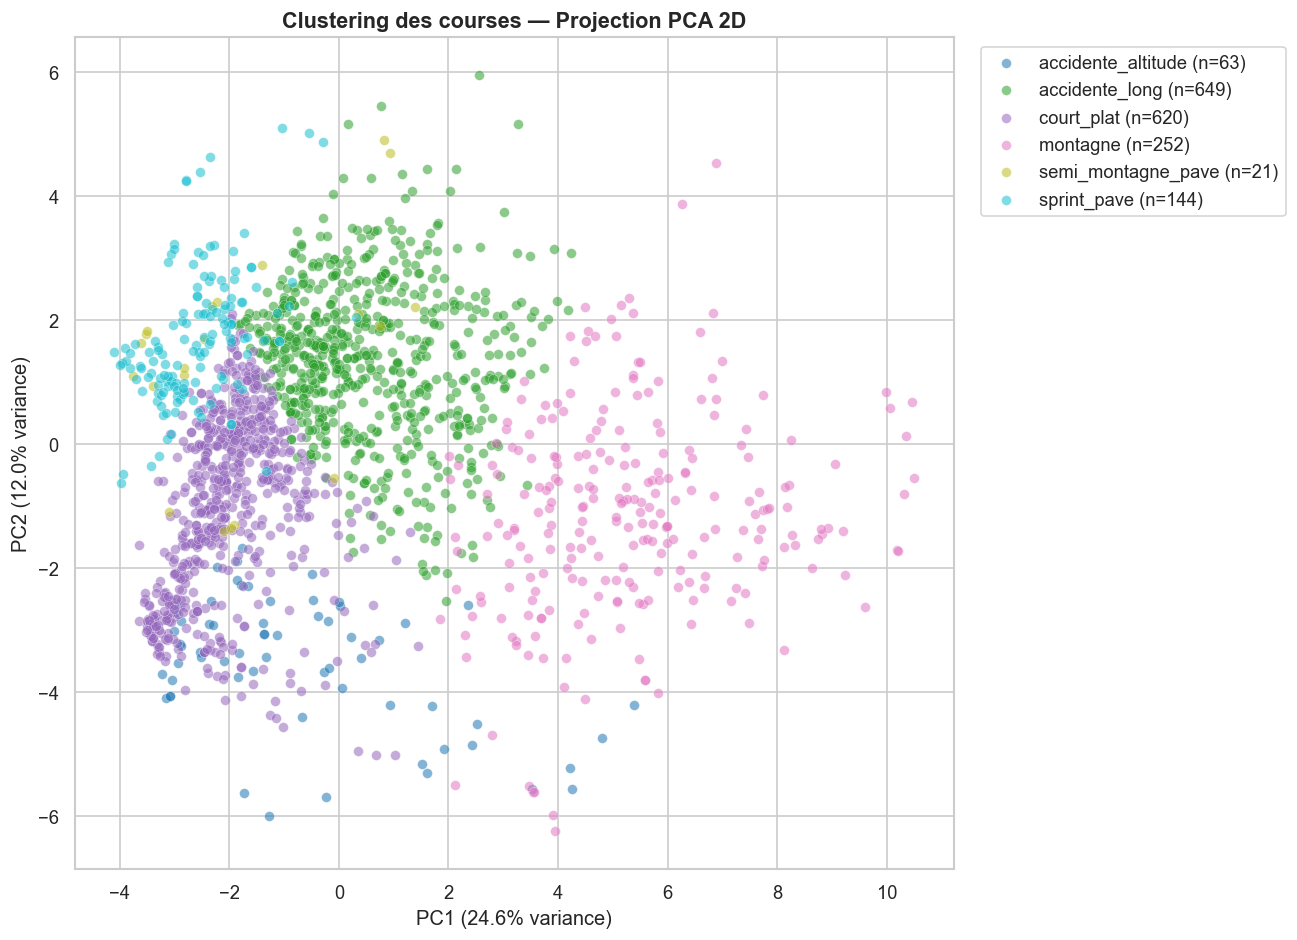

In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'Variance expliquee PC1+PC2 : {pca.explained_variance_ratio_.sum():.1%}')
print(f'PC1 : {pca.explained_variance_ratio_[0]:.1%}')
print(f'PC2 : {pca.explained_variance_ratio_[1]:.1%}')

fig, ax = plt.subplots(figsize=(11, 8))
cluster_labels = df_cluster['cluster_label'].values
unique_labels = sorted(set(cluster_labels))
colors = cm.tab10(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    mask = cluster_labels == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colors[i]], label=f'{label} (n={mask.sum()})',
               alpha=0.55, s=35, edgecolors='white', linewidths=0.3)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Clustering des courses — Projection PCA 2D', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Exemples de courses par cluster

In [16]:
cols_exemples = ['fichier_gpx', 'annee', 'categorie', 'distance_gpx_km',
                 'denivele_pos', 'n_cols_hc', 'gradient_last_1km', 'cobblestones_km']
cols_exemples = [c for c in cols_exemples if c in df_cluster.columns]

In [30]:
separator = '=' * 60
for label in sorted(df_cluster['cluster_label'].unique()):
    print(f'\n{separator}')
    print(f'CLUSTER : {label.upper()}')
    print(separator)
    sub = df_cluster[df_cluster['cluster_label'] == label]
    wt = sub[sub['categorie'].isin(['1.UWT', '2.UWT'])]
    if len(wt) > 0:
        print(wt[cols_exemples].drop_duplicates('fichier_gpx').head(50).to_string(index=False))
    else:
        print(sub[cols_exemples].head(5).to_string(index=False))


CLUSTER : ACCIDENTE_ALTITUDE
                            fichier_gpx  annee categorie  distance_gpx_km  denivele_pos  n_cols_hc  gradient_last_1km  cobblestones_km
              2024 UAE Tour Stage 5.gpx   2024     2.UWT           182.53       1020.00       0.00               0.00             0.00
2024 Gree - Tour of Guangxi Stage 1.gpx   2024     2.UWT           149.09       1604.00       0.00              -1.30             0.00
2024 Gree - Tour of Guangxi Stage 3.gpx   2024     2.UWT           215.50       2563.00       0.00               0.10             0.00
2024 Gree - Tour of Guangxi Stage 4.gpx   2024     2.UWT           176.59       2835.00       0.00               0.00             0.00
2024 Gree - Tour of Guangxi Stage 5.gpx   2024     2.UWT           166.18       1881.00       0.00              15.90             0.00
2024 Gree - Tour of Guangxi Stage 6.gpx   2024     2.UWT           133.30       1592.00       0.00               0.00             0.00
              2025 UAE To

## 9. Sauvegarde

In [19]:
df_out = df.copy()
df_out['cluster'] = df_cluster['cluster'].reindex(df_out.index)
df_out['cluster_label'] = df_cluster['cluster_label'].reindex(df_out.index)

df_out.to_csv(OUTPUT_CSV, index=False)
print(f'Sauvegarde : {OUTPUT_CSV}')
print(f'Shape : {df_out.shape}')
print(f'\nDistribution finale :')
print(df_out['cluster_label'].value_counts())

Sauvegarde : /Users/arthurdeletang/Desktop/Stage M1/Code/data/matching/all/dataset_clustered.csv
Shape : (1796, 47)

Distribution finale :
cluster_label
accidente_long        649
court_plat            620
montagne              252
sprint_pave           144
accidente_altitude     63
semi_montagne_pave     21
Name: count, dtype: int64
